In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.7.12


In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel
import culRIBayesian.stan_utils as culRIB
import culRIBayesian.dataviz_utils as dv
import importlib

import bayspline as bsl
import bayspar as bsr



In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(66.6667,-18.6667),
        'schouteN_meso003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(0.015,0.280),
        'schouteN_meso003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [7]:
# set the path to local folder other than github
login_name = os.getlogin()

from cmdstanpy import set_cmdstan_path
set_cmdstan_path(f"/home/{login_name}/.cmdstan/cmdstan-2.36.0")

from cmdstanpy import cmdstan_path
print(cmdstan_path())

### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/culRIBayesian/stan_models/'

/home/ronnie-rattan/.cmdstan/cmdstan-2.36.0


# ensure fresh stan models

In [8]:
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"
os.environ["TBB_CXX_TYPE"] = "gcc"
os.environ["CMDSTAN"] = os.path.expanduser("~/.cmdstan/cmdstan-2.36.0")
from culRIBayesian.stan_utils import refresh_stan_models
refresh_stan_models(stan_models_dir=stan_models_path,n_jobs=8, clean=True)

05:28:42 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox


🔧 (Re)compiling 9 Stan model(s) via CmdStanPy…


05:28:47 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox
05:28:47 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox
05:28:51 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox
05:28:51 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv


✅ Compiled: hier_crtp_univ_priorApprox.stan


05:28:56 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv
05:28:56 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv
05:29:01 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv
05:29:01 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv_meanprior_bayes.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv_meanprior_bayes


...

✅ Compiled: jnt_cul_meso_crtp.stan


05:29:56 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
05:29:56 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
05:30:01 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
05:30:01 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv


✅ Compiled: jnt_cul_meso_hier_crtp.stan


05:30:06 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
05:30:06 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
05:30:11 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv


✅ Compiled: jnt_cul_meso_hier_crtp_multiv.stan
🚀 Done compiling Stan models.


In [9]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [10]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_sst = T_da.isel(depth=0).t_an
woas23_sst

<xarray.DataArray 't_an' (time: 1, lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
    depth    float32 0.0
  * time     (time) float32 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [11]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds_tmp = xr.open_dataset(os.path.join(fpath, fname))
ocean_properties_ds = xr.merge(
    [ocean_properties_ds_tmp, woas23_sst.rename('sst')],
    compat='override',
    join='override'
)
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    depth          float32 0.0
  * time           (time) float64 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                (lat: 720, lon: 1440)
Coordinates:
  * lat                    (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                    (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables: (12/14)
    region_ID              (lon, lat) float64 ...
    tex_count              (lon, lat) float64 ...
    tex_median             (lon, lat) float64 ...
    tex_mean               (lon, lat) float64 ...
    tex_std                (lon, lat) float64 ...
    scaledRI_count         (lon, lat) float64 ...
    ...                     ...
    scaledRI_std           (lon, lat) float64 ...
    gdgt23ratio_count      (lon, lat) float64 ...
    gdgt23ratio_median     (lon, lat) float64 ...
    gdgt23ratio_mean       (lon, lat) float64 ...
    gdgt23ratio_std        (lon, lat) float64 ...
    modernWaterDepth_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [12]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])

coretop_df = coretop_ds_merged.to_dataframe()
coretop_df = coretop_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041
1470,86.625,152.125,1878.0,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,...,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909,0.0,-1.57041
1471,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180
1472,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371


In [13]:
# # ─── prepare sample points ────────────────────────────────────────────────────
# xx = np.linspace(-4, 50, 200)

# # ─── filter & group your data ──────────────────────────────────────────────────
# plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
# min_count = 2
# groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# # ─── build the figure with one trace per strain per model ─────────────────────
# fig = go.Figure()

# fig.add_trace(go.Scatter(
#     x=coretop_df['t_sf2tc_avg'],
#     y=coretop_df['scaledRI_median'],
#     mode='markers',
#     marker=dict(color='rgba(178,178,178,1.000)', size=5),
#     name='Core-top data',
#     showlegend=True   # you can allow toggling it via legend if you like
# ))
# core_idx = 0  # index of this core-top trace

# # ─── add global fits ────────────────────────────────────────────────
# X_all = plot_data['Temperature'].values.reshape(-1,1)
# y_all = plot_data['scaledRI'].values

# # -- Linear fit --
# ols_all = LinearRegression().fit(X_all, y_all)
# y_lin_all = ols_all.predict(xx.reshape(-1,1))


# # -- Logistic fixed upper --
# p0f = [25, 0.1, 0.1]
# bf = (0, [50,1,1])
# popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
# y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
# r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# # -- Full logistic --
# p0_all = [25,0.1,0.1,0.1]
# bnd_all = (0, [50,1,1,1])
# popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
# y_logi_all = logistic(xx, *popt_all)
# r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
#     ("Logistic fixed", y_logif_all, r2_logif_all),
#     ("Logistic", y_logi_all, r2_logi_all)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso -- {model} (R²={r2:.2f})",
#         visible=True
#     ))

# ### add X_all and y_all with coretop data and fit the glob_cul_meso_crtp
# X_all_full = np.concatenate((coretop_df['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
# y_all_full = np.concatenate((coretop_df['scaledRI_median'].values, plot_data['scaledRI'].values))

# # -- Linear fit --
# ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
# y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# # -- Logistic fixed upper --
# p0f_full = [25, 0.1, 0.1]
# bf_full = (0, [50,1,1])
# popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
# y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
# r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# # -- Full logistic --
# p0_all_full = [25,0.1,0.1,0.1]
# bnd_all_full = (0, [50,1,1,1])
# popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
# y_logi_all_full = logistic(xx, *popt_all_full)
# r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
#     ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
#     ("Logistic", y_logi_all_full, r2_logi_all_full)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso_crtp -- {model} (R²={r2:.2f})",
#         visible=True
#     ))
    
# # ─── add all your strain traces ───────────────────────────
# for strain in groups:
#     df = plot_data[plot_data['Strains_edited'] == strain]
#     X = df['Temperature'].values.reshape(-1,1)
#     y = df['scaledRI'].values
    
#     # -- Linear fit --
#     ols = LinearRegression().fit(X, y)
#     y_lin = ols.predict(xx.reshape(-1,1))
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_lin, 
#         mode='lines',
#         name=f"{strain} -- Linear (R²={ols.score(X,y):.2f})",
#         visible=(strain == groups[0])  # only first strain visible initially
#     ))
    
#     # -- Logistic fixed upper --
#     p0f = [25, 0.1, 0.1]
#     bf = (0, [50,1,1])
#     popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
#     y_logf = logistic_fixed_upper(xx, *popt_f)
#     r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_logf,
#         mode='lines',
#         name=f"{strain} -- Logistic fixed (R²={r2_f:.2f})",
#         visible=False
#     ))
    
#     # -- Full logistic --
#     p0 = [25,0.1,0.1,0.1]
#     bnd = (0, [50,1,1,1])
#     popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
#     y_log = logistic(xx, *popt)
#     r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_log,
#         mode='lines',
#         name=f"{strain} -- Logistic (R²={r2:.2f})",
#         visible=False
#     ))
    
#     # -- Always-on scatter of raw data --
#     fig.add_trace(go.Scatter(
#         x=df['Temperature'], y=df['scaledRI'],
#         mode='markers',
#         marker=dict(size=6, line=dict(width=1, color='black')),
#         name=f"{strain} -- data",
#         visible=True
#     ))
# # build a mapping strain → color
# palette1 = px.colors.qualitative.Set1
# palette2 = px.colors.qualitative.Set2

# # make one long list
# all_colors = palette1 + palette2

# # then map strains in order
# strain_colors = {
#     strain: all_colors[i % len(all_colors)]
#     for i, strain in enumerate(groups)
# }

# # now loop through all traces
# for trace in fig.data:
#     # The “cultures + mesocosm only” global fit
#     if trace.name.startswith("glob_cul_meso --"):
#         trace.update(line=dict(
#             color="black",   # pick any CSS name or hex code
#             dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
#             width=4              # thicker line
#         ))

#     # The “cultures + mesocosm + coretop” global fit
#     elif trace.name.startswith("glob_cul_meso_crtp --"):
#         trace.update(line=dict(
#             color="black",
#             dash="dashdot",
#             width=3
#         ))
        
#     # skip the core-top (and any other truly global or background traces)
#     elif trace.name == "Core-top data":
#         continue

#     # split off the strain name (everything before the “ – ”)
#     strain = trace.name.split(" -- ")[0]

#     # pick a color: if it’s one of our strains, use its palette color;
#     # otherwise (e.g. “Global”) fall back to black or whatever you like
#     col = strain_colors.get(strain, "black")

#     # apply to both marker & line
#     trace.update(
#         marker=dict(color=col),
#         line=dict(color=col)
#     )



# # Hide all line traces (fits) by default, leave markers visible
# for trace in fig.data:
#     if "lines" in trace.mode:
#         trace.visible = "legendonly"
#     else:
#         trace.visible = True

# # # Make “raw data” the initial visibility state:
# # for tr in fig.data:
# #     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
# #         tr.visible = True
# #     else:
# #         tr.visible = False
        


# # reposition the model‐dropdown as a vertical nav bar on the left
# fig.update_layout(

#     autosize=False,     # turn off responsive “fill the container”
#     width=900,          # fixed pixel width
#     height=500,         # fixed pixel height
#     margin=dict(l=40, r=40, t=50, b=40),

#     title="Scaled RI vs Temperature",
#     xaxis_title="Temperature (°C)",
#     yaxis_title="Scaled RI",
    
#     yaxis=dict(
#         range=[0.1, 1.1],
#         autorange=False    # turn off auto‐scaling
#     ),

#     # put the legend also on the left, so users can click each strain on/off
#     legend=dict(
#         traceorder="normal",
#         orientation="v",
#         x=1.13,      # just inside the left margin
#         y=0.5,
#         xanchor="left",
#         yanchor="middle",
#         itemsizing="constant"
#     ),
#     template='seaborn',
#     font=dict(
#         family="TeX Gyre Heros",
#         size=14,
#         color="black"
#     ),
    
# )

# # lock X/Y so the units match (remove if you don’t want a 1:1 scale)
# fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# # set a default
# # fig.update_layout(template="plotly_white")

# fig.show()

# # in your Python script / notebook:
# fig.write_html(
#   os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
#   include_plotlyjs="cdn",   # pull Plotly.js from the CDN
#   full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
# )


In [14]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df


,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1468,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041
1469,86.625,152.125,1878.0,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,...,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909,0.0,-1.57041
1470,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180
1471,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371


# Input Data for stan models

In [15]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()



# Calibration posteriors

## jnt_cul_meso

In [18]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()

# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
}

stan_file_name = 'jnt_cul_meso'
jnt_cul_meso_post_ds, diag = culRIB.get_posterior(data, 
                                                  stan_file_name,
                                                  temptype='cultureT')


# Save posteriors
culRIB.save_posterior(jnt_cul_meso_post_ds)

05:31:31 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

05:31:31 - cmdstanpy - INFO - CmdStan done processing.
05:31:31 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 31, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 1.20948, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 31, column 2 to column 29)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 43, column 2 to column 64)
	Exception: beta_lpdf: Random variable is 2.69441, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan', line 31, column 2 to column 29)
Exception: be


Sampling completed in 0.4 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_cultureT.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_cultureT.nc')

## hier_crtp | prior approximation

In [19]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_univ_prior_approx_post_ds, diag = culRIB.get_posterior(data_normal_prior, 
                                                                 stan_file_name,
                                                                 temptype='thermoT',)
# Save posteriors
culRIB.save_posterior(hier_crtp_univ_prior_approx_post_ds)

###################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

data_normal_prior = {
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_sst_univ_prior_approx_post_ds, diag = culRIB.get_posterior(data_normal_prior, 
                                                                 stan_file_name,
                                                                 temptype='sst',)
# Save posteriors
culRIB.save_posterior(hier_crtp_sst_univ_prior_approx_post_ds)

05:31:34 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

05:31:38 - cmdstanpy - INFO - CmdStan done processing.
05:31:38 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
	Exception


Sampling completed in 1.9 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorApprox_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorApprox_sst.nc')

## jnt_cul_meso_crtp

In [20]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_post_ds, diag = culRIB.get_posterior(data, 
                                                       stan_file_name,
                                                       temptype='thermoT')
display(jnt_cul_meso_crtp_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_crtp_post_ds)

##########################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_sst_post_ds, diag = culRIB.get_posterior(data, 
                                                           stan_file_name,
                                                           temptype='sst')
display(jnt_cul_meso_crtp_sst_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_crtp_sst_post_ds)


05:31:39 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

05:31:45 - cmdstanpy - INFO - CmdStan done processing.
05:31:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 42, column 2 to column 65)
	Exception: beta_lpdf: Random variable is 1.23289, but must be in the interval [0, 1] (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 40, column 2 to column 66)
Exception: 


Sampling completed in 3.2 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



<xarray.Dataset>
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmesocore       (draw) float64 29.16 29.16 30.02 ... 29.77 29.53 29.96
    k_culmesocore        (draw) float64 0.1061 0.1104 0.1155 ... 0.1139 0.1127
    b_culmesocore        (draw) float64 0.4134 0.4178 0.4332 ... 0.4271 0.4282
    sigma_scaledRI_cul   (draw) float64 0.08208 0.07847 ... 0.07157 0.08025
    sigma_scaledRI_meso  (draw) float64 0.08081 0.07267 ... 0.07651 0.06484
    sigma_scaledRI_crtp  (draw) float64 0.06099 0.0616 ... 0.06073 0.06156
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_crtp
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-10T05:31:45.845805
    run_duration (sec):  3.2
    temptype:            sst
    ...                  ...
    scaledRI_crtp_mean:  0.5558931343738719
    scaledRI_crtp_std:   0.11163760429983549
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1464
    priors:              ['t0_culmesocore: normal(20, 20) T[-4, ]', 'k_culmes...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst.nc')

## jnt_cul_meso_hier_crtp

In [21]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()


### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp'
jnt_cul_meso_hier_crtp_post_ds, diag = culRIB.get_posterior(data, 
                                                            stan_file_name,
                                                            temptype='thermoT',)
display(jnt_cul_meso_hier_crtp_post_ds)
# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_post_ds)

###########################################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp'
jnt_cul_meso_hier_crtp_sst_post_ds, diag = culRIB.get_posterior(data, 
                                                            stan_file_name,
                                                            temptype='sst',)
display(jnt_cul_meso_hier_crtp_sst_post_ds)
# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_post_ds)

05:31:45 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

05:32:15 - cmdstanpy - INFO - CmdStan done processing.
05:32:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 78, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 78, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 78, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 62, column 4 to column 65)
Consider re-running with sh


Sampling completed in 16.8 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
29 of 1000 (2.90%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmeso           (draw) float64 29.88 29.09 28.63 ... 28.19 29.62 29.64
    k_culmeso            (draw) float64 0.1466 0.123 0.1312 ... 0.1392 0.1518
    b_culmeso            (draw) float64 0.3981 0.3896 0.3861 ... 0.4085 0.4108
    t0_crtp              (draw) float64 29.58 29.48 29.6 ... 29.75 29.48 29.5
    k_crtp               (draw) float64 0.1109 0.1075 0.1094 ... 0.1086 0.1129
    b_crtp               (draw) float64 0.4235 0.4207 0.4179 ... 0.4209 0.4236
    sigma_t0_culmeso     (draw) float64 2.235 1.227 1.526 ... 0.4553 0.2548
    sigma_k_culmeso      (draw) float64 0.07286 0.137 0.1721 ... 0.0432 0.03899
    sigma_b_culmeso      (draw) float64 0.2919 0.5309 0.6251 ... 0.2164 0.3402
    sigma_scaledRI_cul   (draw) float64 0.06778 0.07066 ... 0.0674 0.07106
    sigma_scaledRI_meso  (draw) float64 0.0884 0.08661 0.09756 ... 0.1269 0.1172
    sigma_scaledRI_crtp  (draw) float64 0.06172 0.06232 0.06189 ... 0.0624 0.061
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_hier_crtp
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-10T05:32:15.681977
    run_duration (sec):  16.86
    temptype:            sst
    ...                  ...
    scaledRI_crtp_mean:  0.5558931343738719
    scaledRI_crtp_std:   0.11163760429983549
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1464
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_sst.nc')

['t0', 'k', 'b']


(<Figure size 900x400 with 3 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>]], dtype=object))

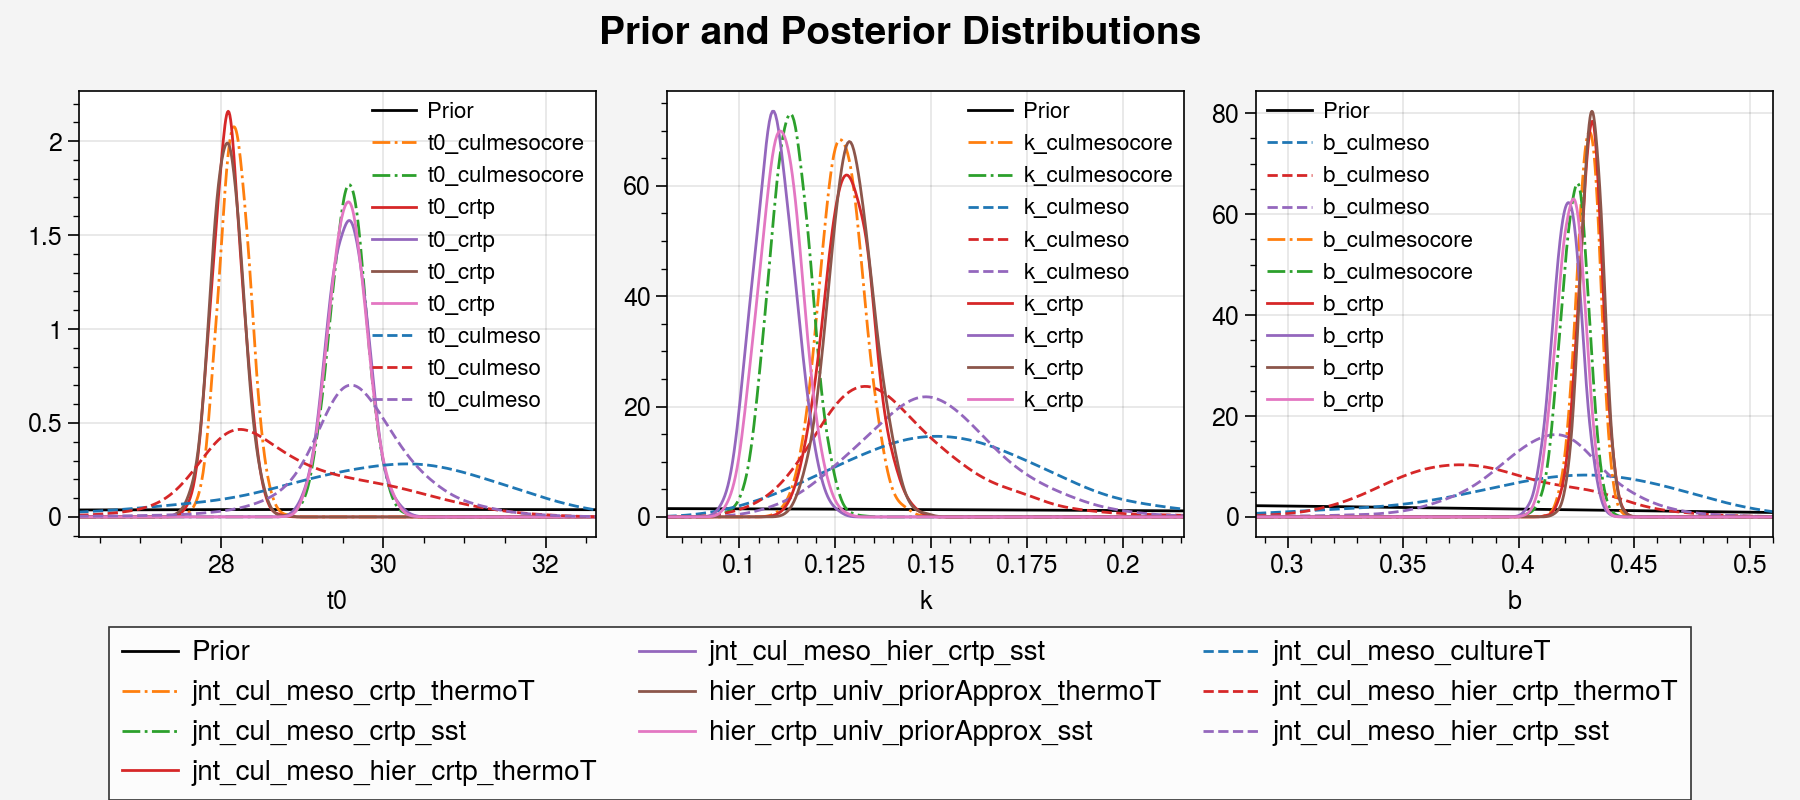

In [22]:
priors = jnt_cul_meso_post_ds.attrs['priors']
dv.plot_prior_distributions(priors,
                            posterior_datasets=[
                                jnt_cul_meso_post_ds,
                                jnt_cul_meso_crtp_post_ds,
                                jnt_cul_meso_crtp_sst_post_ds,
                                jnt_cul_meso_hier_crtp_post_ds,
                                jnt_cul_meso_hier_crtp_sst_post_ds,
                                # hier_crtp_univ_prior_logmixture_post_ds,
                                hier_crtp_univ_prior_approx_post_ds,
                                # hier_crtp_sst_univ_prior_logmixture_post_ds,
                                hier_crtp_sst_univ_prior_approx_post_ds
                                ],
                            use_linestyle_by_param=True,
                            show_histogram=False,
                            set_linewidth=1,
                            set_bottom_space=0.2,
                            set_fig_height_factor=4
                            )

## jnt_cul_meso_hier

In [23]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_multiv_g23r_post_ds, diag = culRIB.get_posterior(data, 
                                                                        stan_file_name,
                                                                        temptype='thermoT')
display(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

#####################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds, diag = culRIB.get_posterior(data, 
                                                                            stan_file_name,
                                                                            temptype='sst',)
display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

05:32:19 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

05:33:08 - cmdstanpy - INFO - CmdStan done processing.
05:33:08 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66


Sampling completed in 19.3 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
20 of 1000 (2.00%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 27.67 27.21 26.15 ... 29.33 30.58
    k_culmeso               (draw) float64 0.1274 0.1199 ... 0.1252 0.1767
    b_culmeso               (draw) float64 0.3554 0.3096 ... 0.3691 0.4544
    t0_crtp                 (draw) float64 27.6 27.74 27.88 ... 27.68 27.44
    k_crtp                  (draw) float64 0.1066 0.1111 ... 0.1077 0.1079
    b_crtp                  (draw) float64 0.4457 0.4448 ... 0.4448 0.4414
    ...                      ...
    sigma_t0_culmeso        (draw) float64 0.1445 0.9962 1.517 ... 1.689 2.74
    sigma_k_culmeso         (draw) float64 0.1737 0.7583 ... 0.04506 0.1228
    sigma_b_culmeso         (draw) float64 0.1705 1.203 ... 0.05882 0.3672
    sigma_scaledRI_cul      (draw) float64 0.07286 0.07463 ... 0.07603 0.07724
    sigma_scaledRI_meso     (draw) float64 0.09948 0.09548 ... 0.1094 0.119
    sigma_scaledRI_crtp     (draw) float64 0.05568 0.05592 ... 0.05727 0.05873
Attributes: (12/31)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-10T05:33:08.806283
    run_duration (sec):     19.34
    temptype:               sst
    ...                     ...
    gdgt23ratio_crtp_std:   3.477076979951923
    gdgt23ratio_crtp_min:   0.7564253358305837
    gdgt23ratio_crtp_max:   35.072441830778935
    gdgt23ratio_crtp_len:   1464
    use_gdgt23ratio:        1
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio.nc')

In [24]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

no3_cutoff_values = [1, 1.5, 2, 2.5, 5, 10, 15,100]
for no3_cutoff in no3_cutoff_values:
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(t_crtp),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds, diag = culRIB.get_posterior(data, 
                                                                                stan_file_name,
                                                                                temptype='thermoT',
                                                                                )
    display(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

    # Save posteriors
    culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

05:33:08 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

05:36:15 - cmdstanpy - INFO - CmdStan done processing.
05:36:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66


Sampling completed in 18.0 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
39 of 1000 (3.90%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 29.81 25.95 29.23 ... 27.82 30.97
    k_culmeso               (draw) float64 0.1631 0.098 0.1545 ... 0.1251 0.1893
    b_culmeso               (draw) float64 0.43 0.2952 0.43 ... 0.3519 0.4633
    t0_crtp                 (draw) float64 27.21 27.74 27.84 ... 27.94 27.77
    k_crtp                  (draw) float64 0.1129 0.1185 ... 0.1163 0.1297
    b_crtp                  (draw) float64 0.4657 0.4611 ... 0.4617 0.4737
    ...                      ...
    sigma_t0_culmeso        (draw) float64 5.448 1.077 0.8419 ... 0.2808 2.413
    sigma_k_culmeso         (draw) float64 0.1745 0.1281 ... 0.3113 0.08528
    sigma_b_culmeso         (draw) float64 0.07393 1.381 0.1212 ... 0.1122 0.553
    sigma_scaledRI_cul      (draw) float64 0.06907 0.08903 ... 0.08147 0.07059
    sigma_scaledRI_meso     (draw) float64 0.09373 0.09812 ... 0.07598 0.1244
    sigma_scaledRI_crtp     (draw) float64 0.05278 0.05598 ... 0.05535 0.05396
Attributes: (12/38)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-10T05:36:15.486752
    run_duration (sec):     18.01
    temptype:               thermoT
    ...                     ...
    no3_crtp_min:           0.0002862779365386814
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio_no3_100.0.nc


In [25]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median', 'no3_sf2tc_avg']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

no3_cutoff_values = [1, 1.5, 2, 2.5, 5, 10, 15, 100]
for no3_cutoff in no3_cutoff_values:
    
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(sst_crtp),
        "t_crtp": sst_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds, diag = culRIB.get_posterior(data, 
                                                                                    stan_file_name,
                                                                                    temptype='sst',
                                                                                    )
    display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

    # Save posteriors
    culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

05:36:15 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

05:40:52 - cmdstanpy - INFO - CmdStan done processing.
05:40:52 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66


Sampling completed in 39.9 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
25 of 1000 (2.50%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 29.58 29.7 29.9 ... 30.83 32.0 31.15
    k_culmeso               (draw) float64 0.1995 0.1257 ... 0.1764 0.1725
    b_culmeso               (draw) float64 0.4402 0.3805 0.4167 ... 0.48 0.4381
    t0_crtp                 (draw) float64 29.21 29.78 29.68 ... 29.71 29.29
    k_crtp                  (draw) float64 0.109 0.09878 ... 0.1131 0.1165
    b_crtp                  (draw) float64 0.4662 0.4572 ... 0.4787 0.4681
    ...                      ...
    sigma_t0_culmeso        (draw) float64 0.4406 0.2924 0.5596 ... 2.407 7.215
    sigma_k_culmeso         (draw) float64 0.1092 0.2838 ... 0.03424 0.4113
    sigma_b_culmeso         (draw) float64 0.03248 3.811 ... 0.01004 0.06506
    sigma_scaledRI_cul      (draw) float64 0.07241 0.08418 ... 0.07026 0.07778
    sigma_scaledRI_meso     (draw) float64 0.1281 0.09805 ... 0.1075 0.0876
    sigma_scaledRI_crtp     (draw) float64 0.05718 0.05451 ... 0.05444 0.05612
Attributes: (12/38)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-10T05:40:52.743141
    run_duration (sec):     39.9
    temptype:               sst
    ...                     ...
    no3_crtp_min:           0.0002862779365386814
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio_no3_100.0.nc


In [26]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'no3_sf2tc_avg']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

no3_cutoff_values = [1, 1.5, 2, 2.5, 5, 10, 15,100]
for no3_cutoff in no3_cutoff_values:
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(t_crtp),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        # "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_multiv_no3_post_ds, diag = culRIB.get_posterior(data, 
                                                                            stan_file_name,
                                                                            temptype='thermoT',
                                                                            )
    display(jnt_cul_meso_hier_crtp_multiv_no3_post_ds)

    # Save posteriors
    culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_no3_post_ds)

05:40:52 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

05:43:30 - cmdstanpy - INFO - CmdStan done processing.
05:43:30 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 6


Sampling completed in 18.1 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
39 of 1000 (3.90%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 29.77 30.58 28.0 ... 28.47 29.74
    k_culmeso               (draw) float64 0.1635 0.1514 ... 0.1344 0.1455
    b_culmeso               (draw) float64 0.4264 0.4351 ... 0.3592 0.3989
    t0_crtp                 (draw) float64 29.13 29.77 29.32 ... 29.32 29.92
    k_crtp                  (draw) float64 0.1302 0.1351 ... 0.1325 0.1283
    b_crtp                  (draw) float64 0.4514 0.4625 ... 0.4557 0.4603
    ...                      ...
    sigma_t0_culmeso        (draw) float64 1.631 0.9766 0.7222 ... 0.6877 1.625
    sigma_k_culmeso         (draw) float64 0.2548 0.9698 ... 0.0735 0.3483
    sigma_b_culmeso         (draw) float64 2.037 0.08551 0.2341 ... 1.297 0.5231
    sigma_scaledRI_cul      (draw) float64 0.07829 0.08365 ... 0.07396 0.07756
    sigma_scaledRI_meso     (draw) float64 0.0914 0.1037 ... 0.1117 0.1256
    sigma_scaledRI_crtp     (draw) float64 0.05565 0.05847 ... 0.05772 0.05823
Attributes: (12/32)
    stan_model_name:     jnt_cul_meso_hier_crtp_multiv
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-10T05:43:30.430124
    run_duration (sec):  18.11
    temptype:            thermoT
    ...                  ...
    no3_crtp_min:        0.0002862779365386814
    no3_crtp_max:        33.803863525390625
    no3_crtp_len:        1402
    use_no3:             1
    no3_cutoff:          100.0
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_thermoT_no3_100.0.nc


In [27]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'no3_sf2tc_avg']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

no3_cutoff_values = [1, 1.5, 2, 2.5, 5, 10, 15, 100]
for no3_cutoff in no3_cutoff_values:
    
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(sst_crtp),
        "t_crtp": sst_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        # "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds, diag = culRIB.get_posterior(data, 
                                                                                stan_file_name,
                                                                                temptype='sst',
                                                                                )
    display(jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds)

    # Save posteriors
    culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds)

05:43:30 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

05:46:18 - cmdstanpy - INFO - CmdStan done processing.
05:46:18 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 6


Sampling completed in 20.2 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
68 of 1000 (6.80%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 31.32 31.22 31.53 ... 29.85 29.86
    k_culmeso               (draw) float64 0.1644 0.1497 ... 0.1348 0.1284
    b_culmeso               (draw) float64 0.4576 0.4688 ... 0.3977 0.3799
    t0_crtp                 (draw) float64 31.4 31.28 31.54 ... 31.11 31.11
    k_crtp                  (draw) float64 0.1284 0.1277 ... 0.1346 0.1085
    b_crtp                  (draw) float64 0.4638 0.4638 0.4626 ... 0.468 0.4466
    ...                      ...
    sigma_t0_culmeso        (draw) float64 0.473 0.5312 0.4608 ... 0.6273 2.09
    sigma_k_culmeso         (draw) float64 0.08015 0.08686 ... 0.008401 0.03117
    sigma_b_culmeso         (draw) float64 0.003471 0.003106 ... 4.478 3.398
    sigma_scaledRI_cul      (draw) float64 0.07801 0.07753 ... 0.08088 0.07562
    sigma_scaledRI_meso     (draw) float64 0.08383 0.08892 ... 0.092 0.1108
    sigma_scaledRI_crtp     (draw) float64 0.05782 0.05778 ... 0.05973 0.05785
Attributes: (12/32)
    stan_model_name:     jnt_cul_meso_hier_crtp_multiv
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-10T05:46:18.725278
    run_duration (sec):  20.18
    temptype:            sst
    ...                  ...
    no3_crtp_min:        0.0002862779365386814
    no3_crtp_max:        33.803863525390625
    no3_crtp_len:        1402
    use_no3:             1
    no3_cutoff:          100.0
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_no3_100.0.nc


# Posterior plots --- QC

### 1. Joint culture-mesocosm

['t0', 'k', 'b']


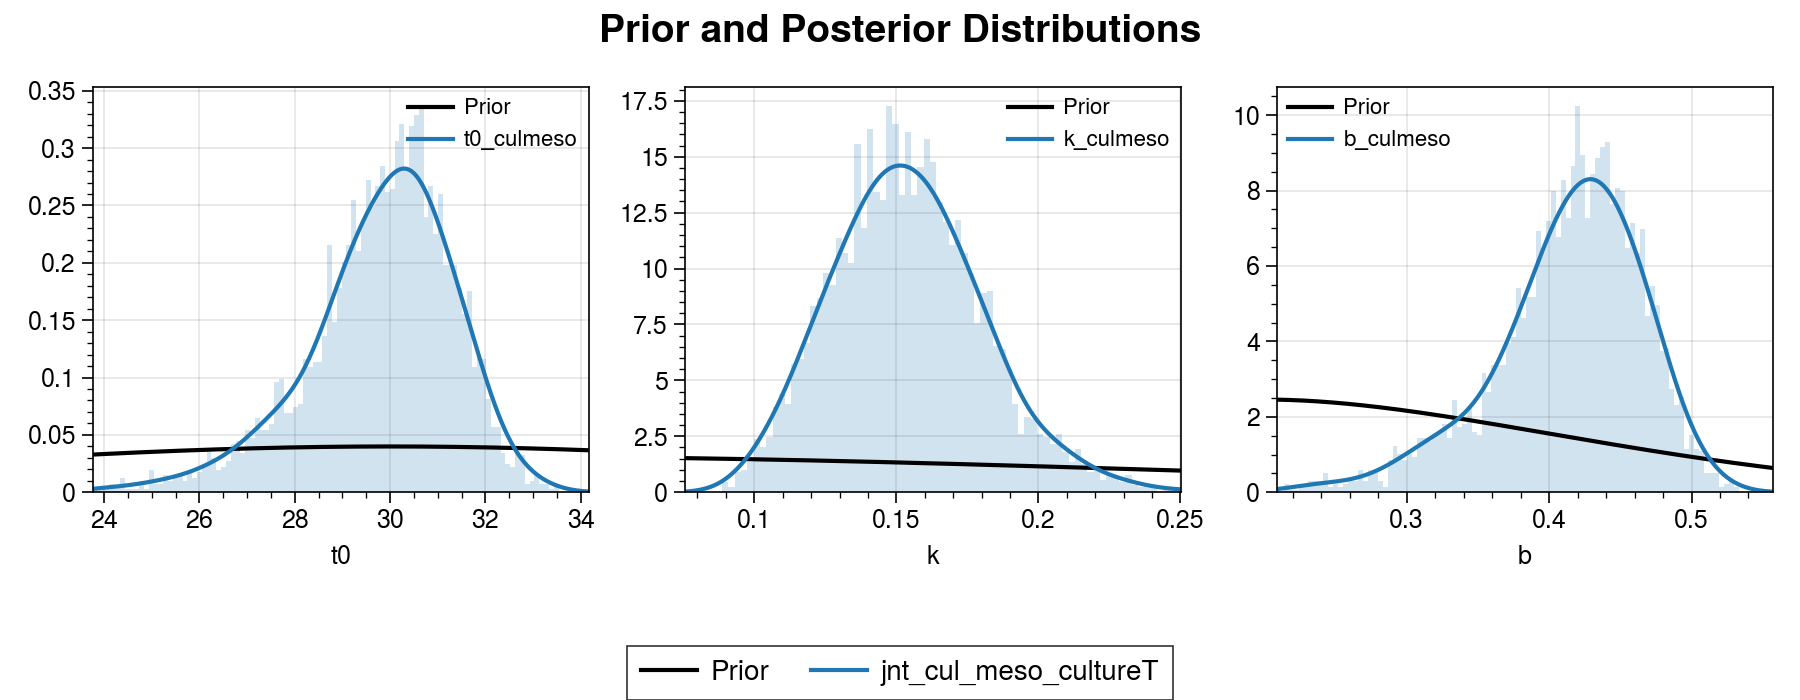

In [28]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[jnt_cul_meso_post_ds]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 2. Joint  culture-mesocosm vs culture-mesocosm-coretop

['t0', 'k', 'b']


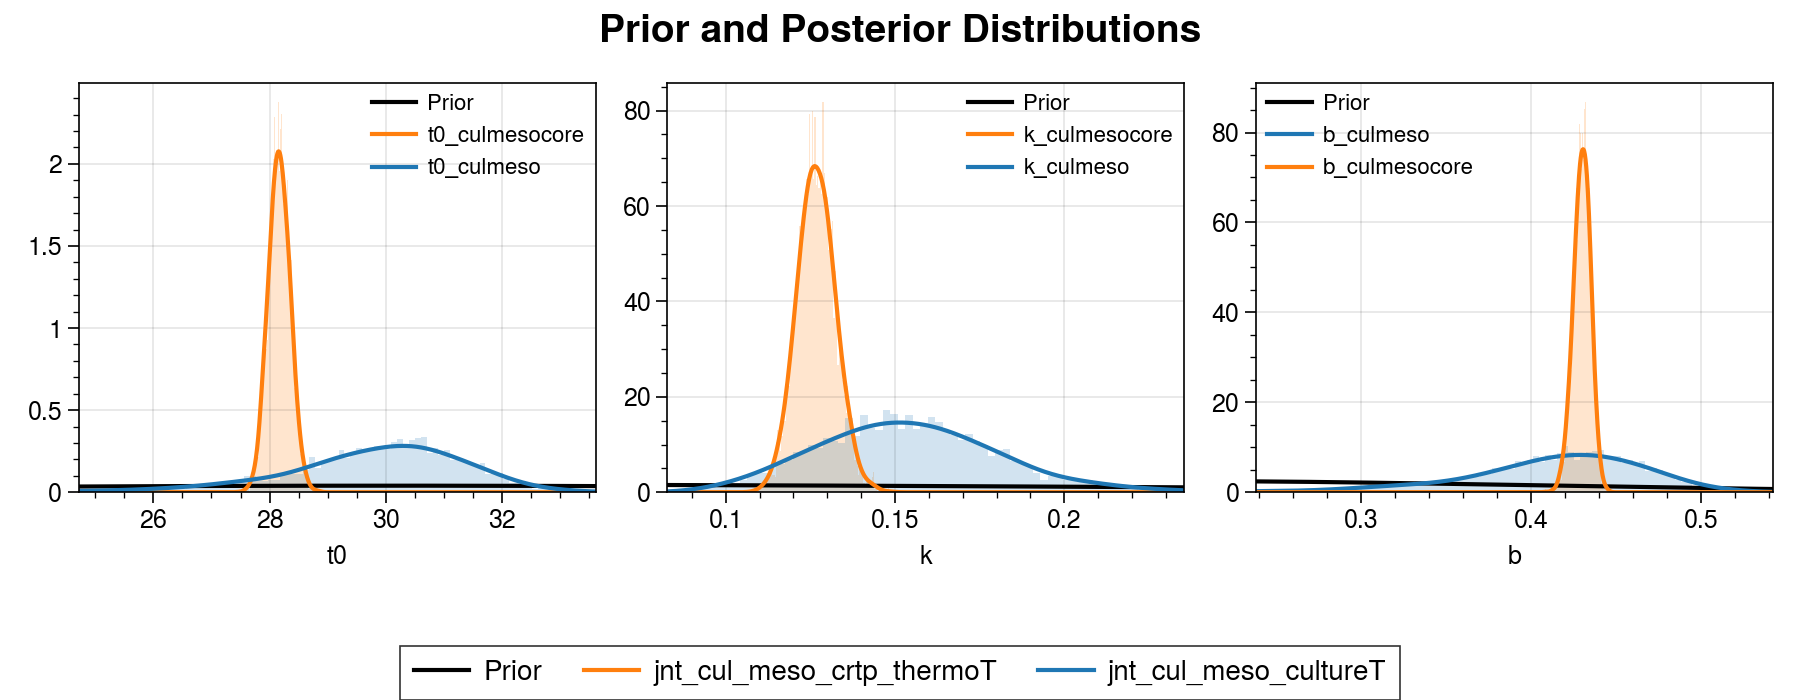

In [29]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        jnt_cul_meso_crtp_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 3. jnt-culture-mesocosm vs jnt-culture-mesocosm-coretop vs jnt-culmeso-hier-crtp

['t0', 'k', 'b']


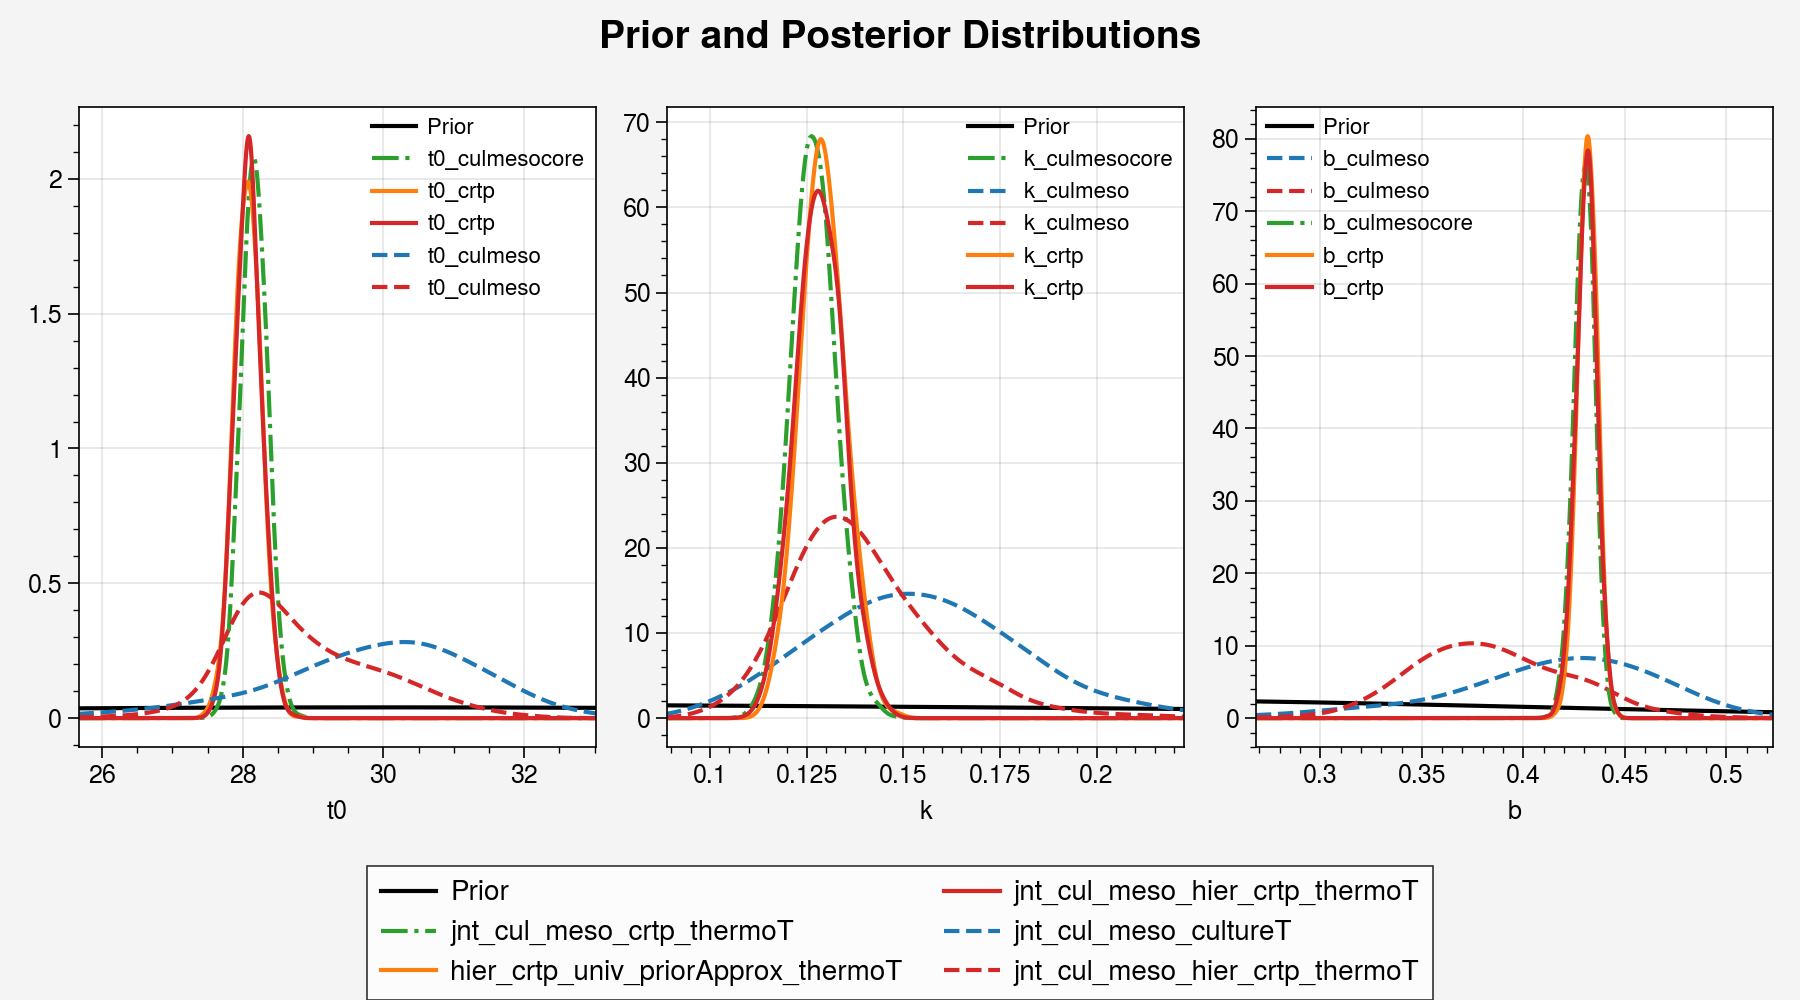

In [30]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_hier_crtp_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


['t0', 'k', 'b']


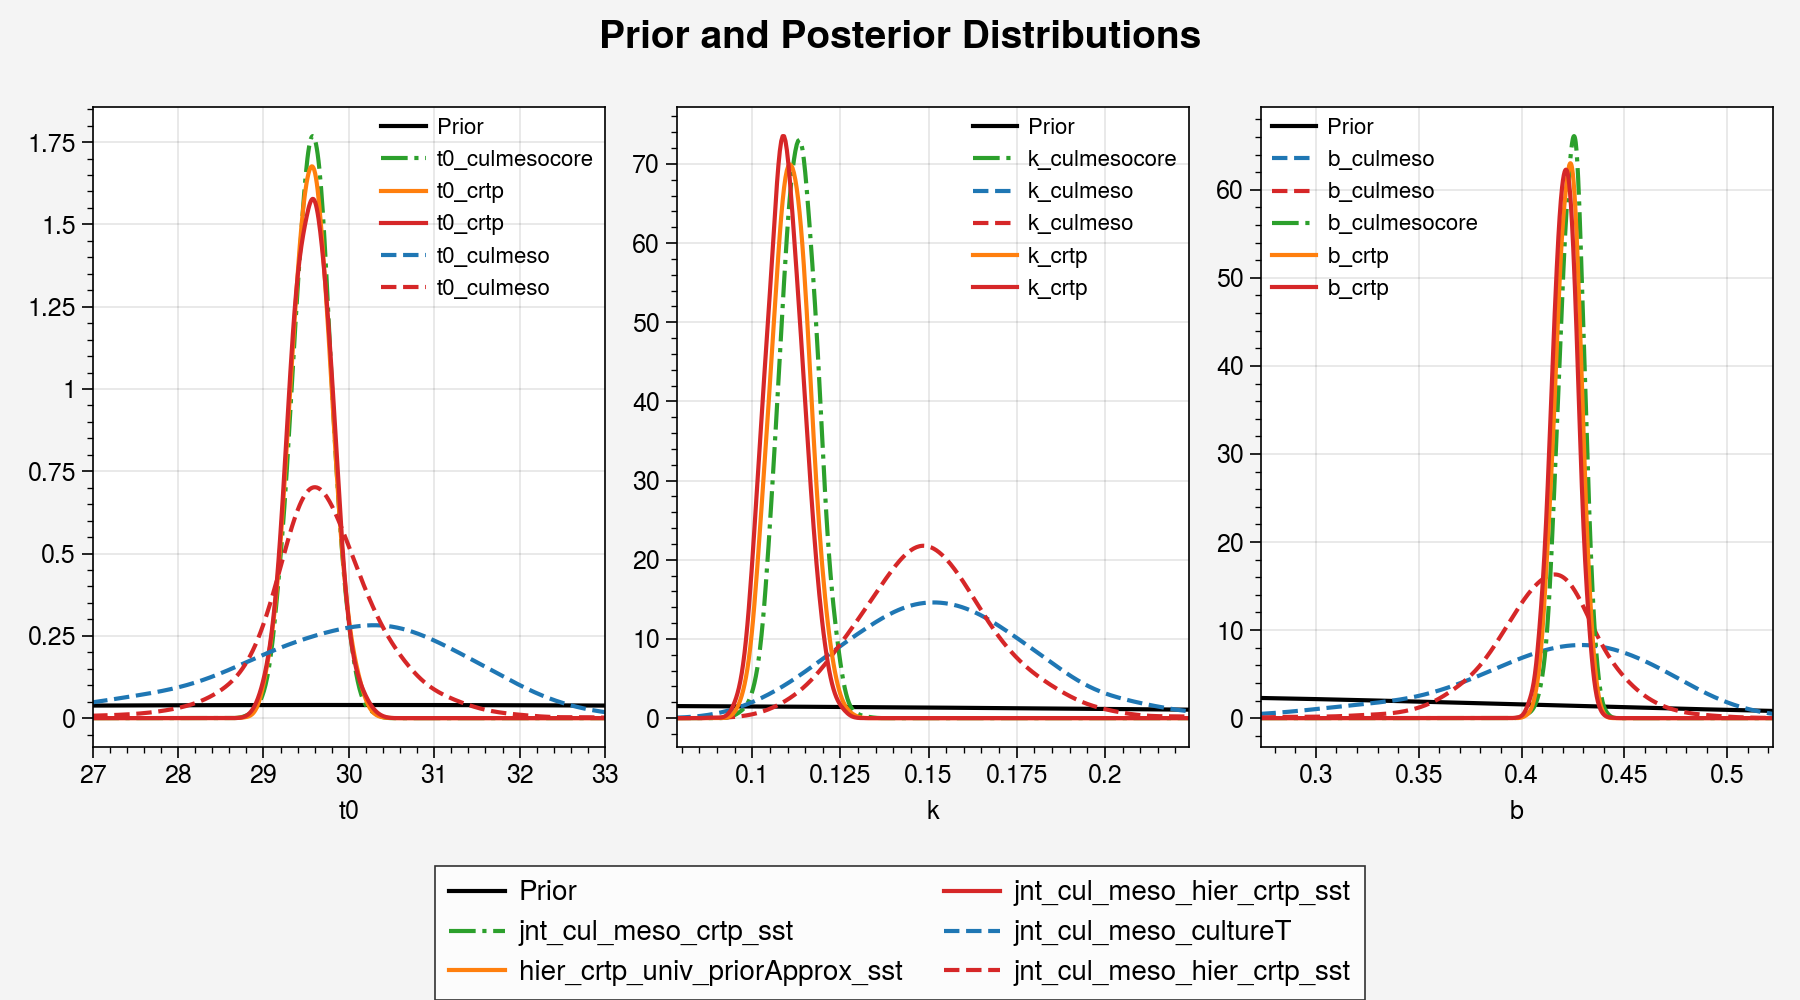

In [31]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_sst_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_sst_post_ds,
        jnt_cul_meso_hier_crtp_sst_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)
axes[0][0].set_xlim(27,33)
# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


['t0', 'k', 'b']


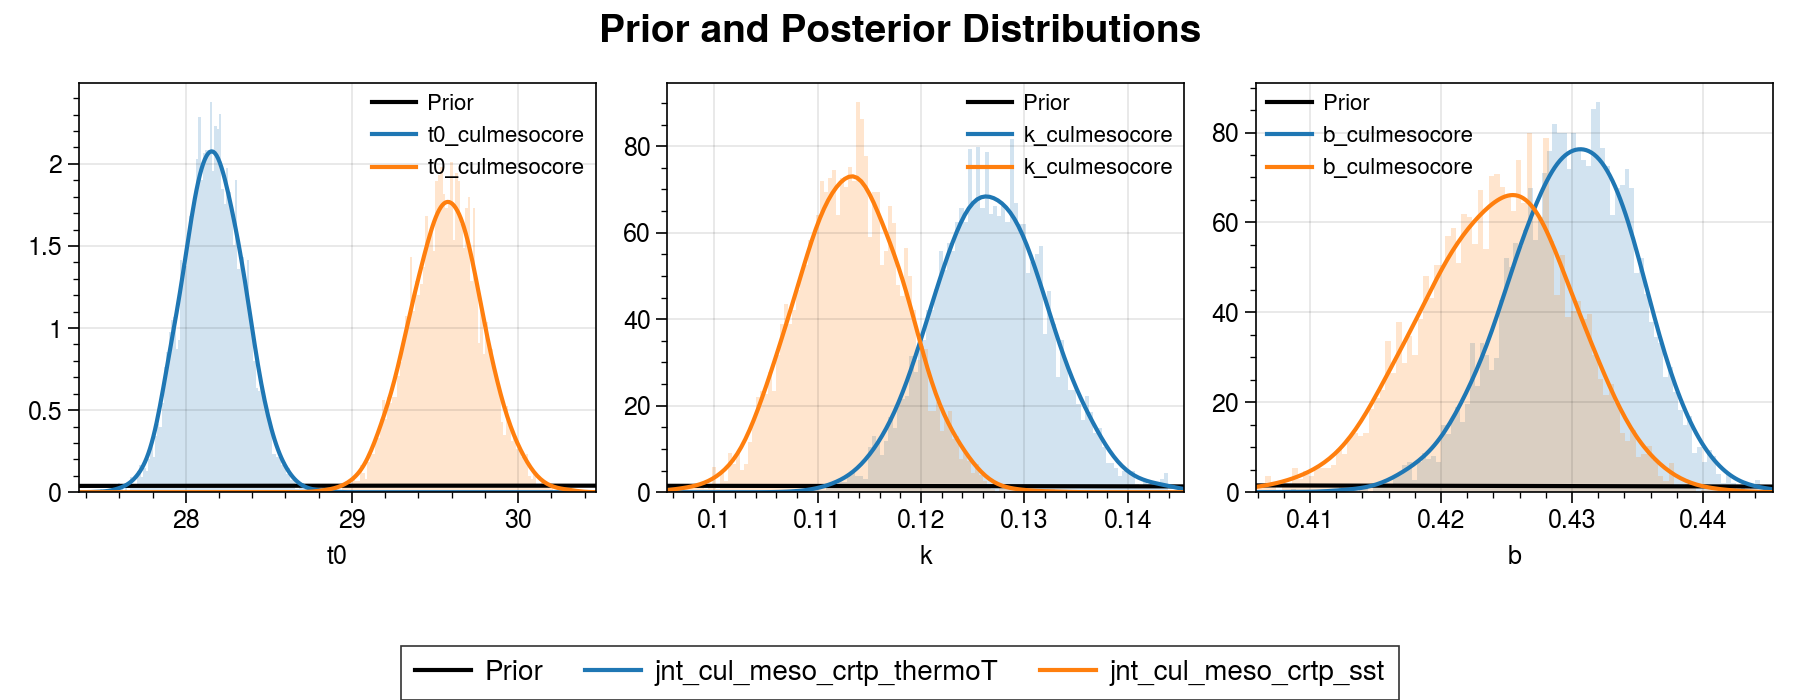

In [32]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_crtp_sst_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


In [33]:
jnt_cul_meso_post_ds.attrs.get('use_gdgt23ratio',0)

0

In [34]:
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio_no3_100.0'
culRIB.load_posterior(stan_file_name)

<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 29.81 25.95 29.23 ... 27.82 30.97
    k_culmeso               (draw) float64 0.1631 0.098 0.1545 ... 0.1251 0.1893
    b_culmeso               (draw) float64 0.43 0.2952 0.43 ... 0.3519 0.4633
    t0_crtp                 (draw) float64 27.21 27.74 27.84 ... 27.94 27.77
    k_crtp                  (draw) float64 0.1129 0.1185 ... 0.1163 0.1297
    b_crtp                  (draw) float64 0.4657 0.4611 ... 0.4617 0.4737
    ...                      ...
    sigma_t0_culmeso        (draw) float64 5.448 1.077 0.8419 ... 0.2808 2.413
    sigma_k_culmeso         (draw) float64 0.1745 0.1281 ... 0.3113 0.08528
    sigma_b_culmeso         (draw) float64 0.07393 1.381 0.1212 ... 0.1122 0.553
    sigma_scaledRI_cul      (draw) float64 0.06907 0.08903 ... 0.08147 0.07059
    sigma_scaledRI_meso     (draw) float64 0.09373 0.09812 ... 0.07598 0.1244
    sigma_scaledRI_crtp     (draw) float64 0.05278 0.05598 ... 0.05535 0.05396
Attributes: (12/39)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-10T05:36:15.486752
    run_duration (sec):     18.01
    temptype:               thermoT
    ...                     ...
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...
    filename:               jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio...

['t0', 'k', 'b', 'beta0_gdgt23ratio', 'beta0_no3']


(25.0, 35.0)

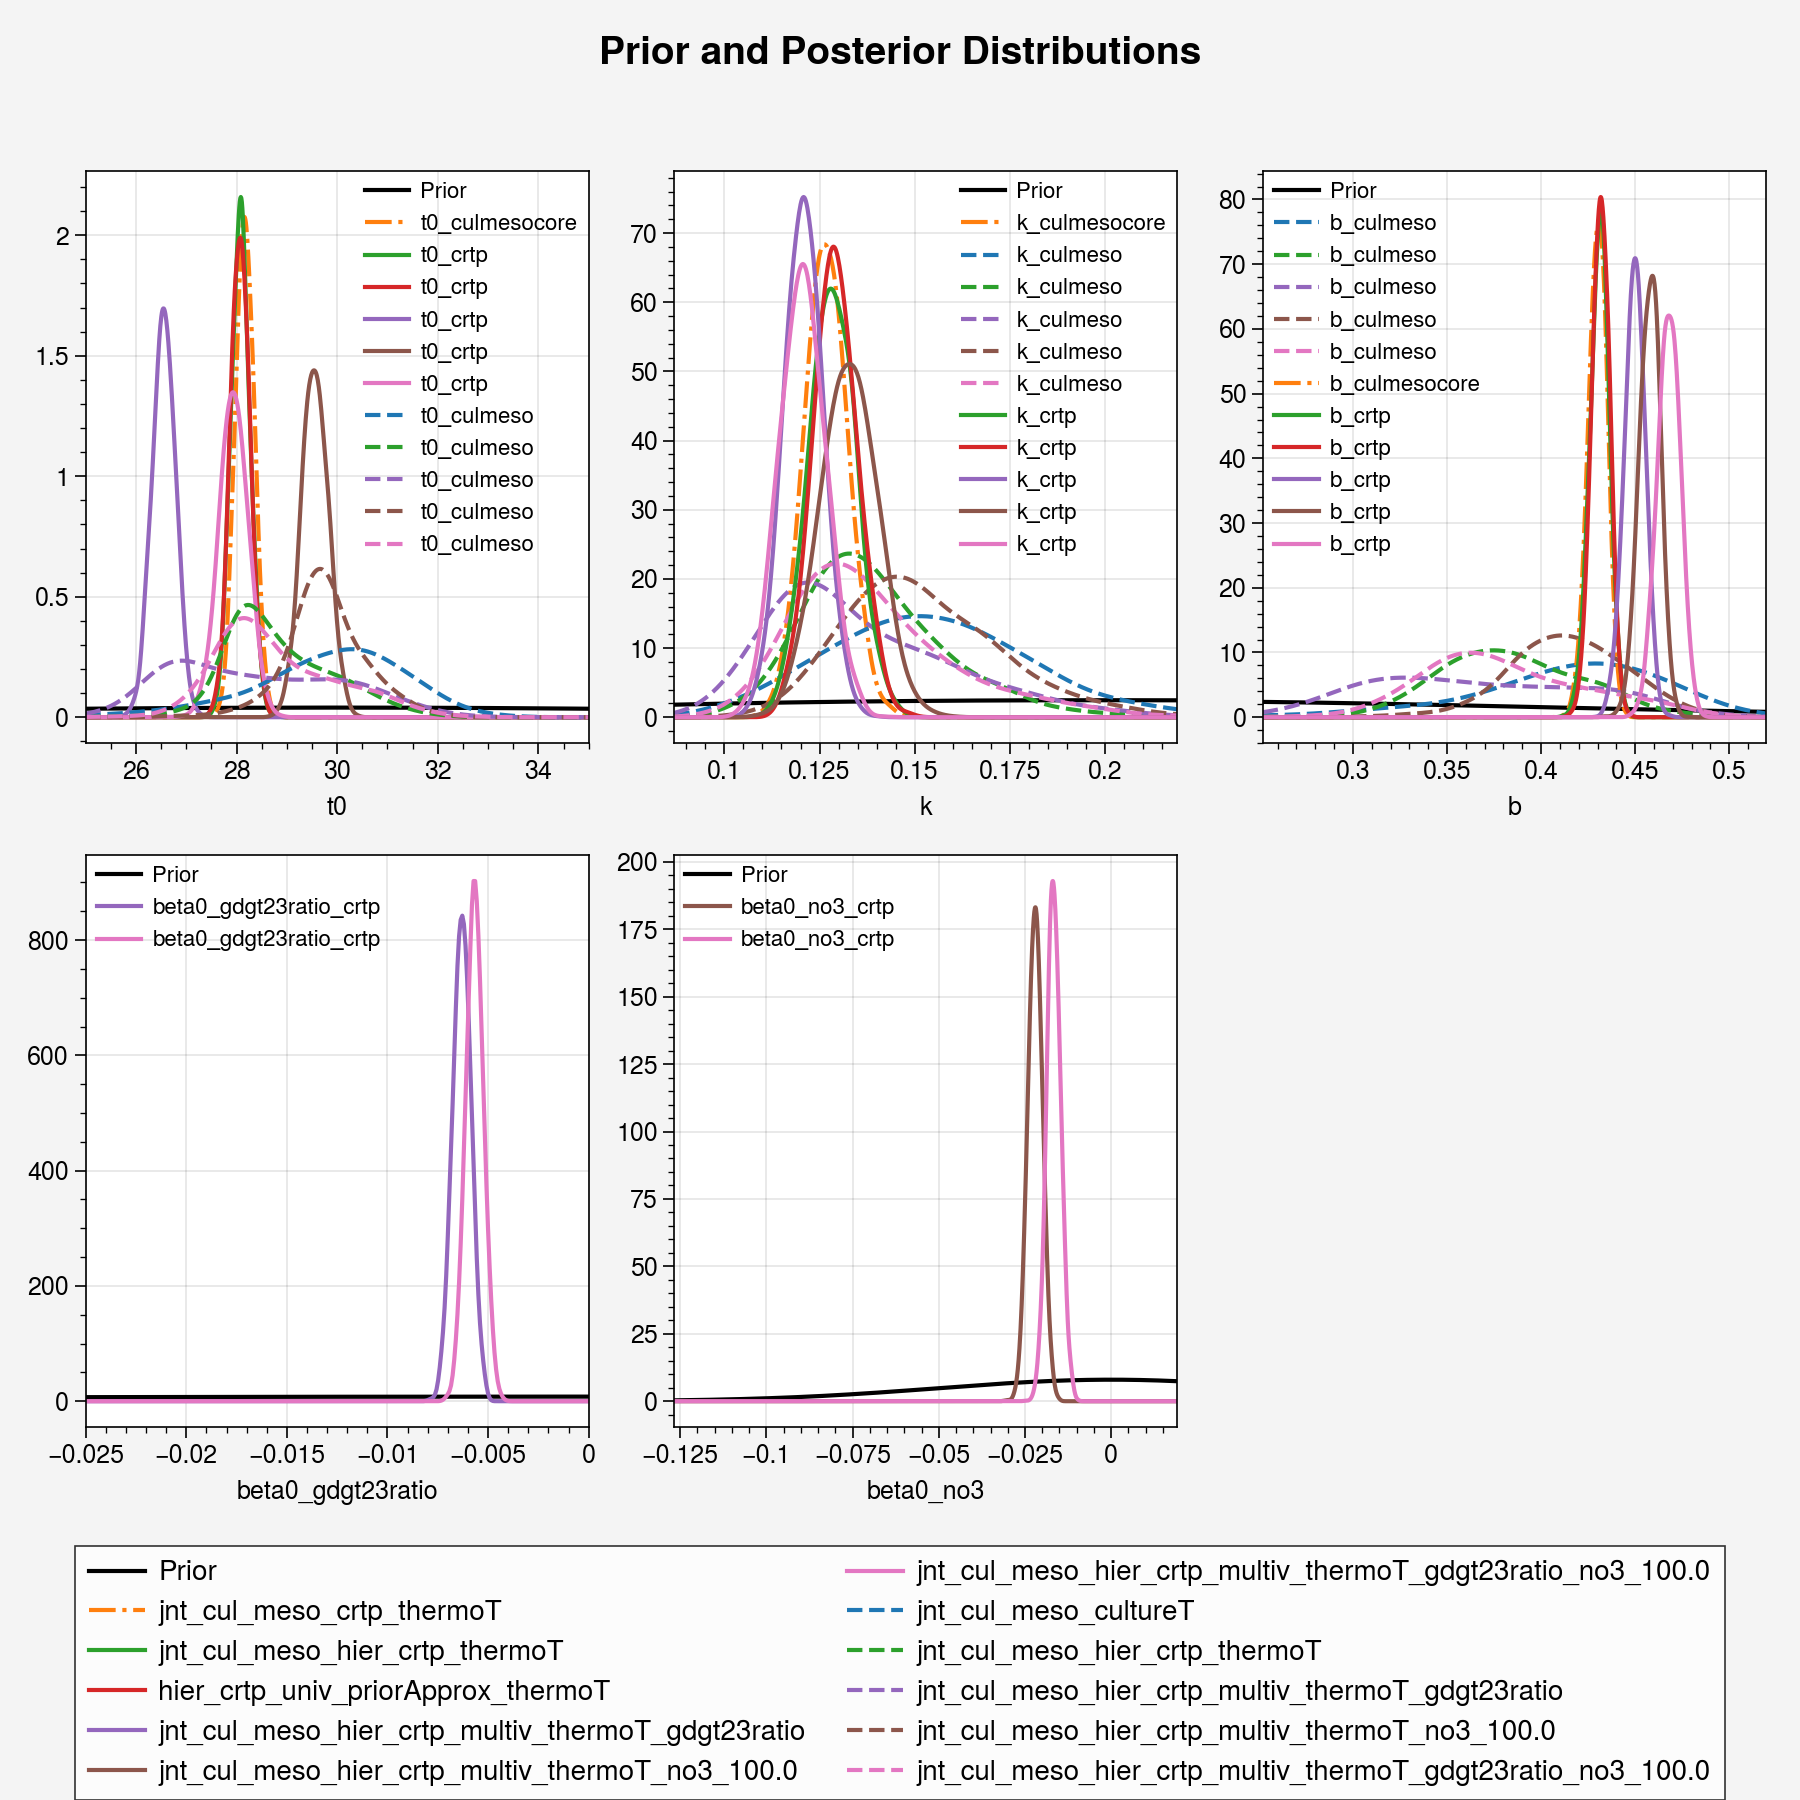

In [35]:
priors = jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds.attrs['priors']

fig, axes = dv.plot_prior_distributions(
                priors,
                posterior_datasets=[
                    jnt_cul_meso_post_ds,
                    jnt_cul_meso_crtp_post_ds,
                    jnt_cul_meso_hier_crtp_post_ds,
                    hier_crtp_univ_prior_approx_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_no3_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds,
                    ],

                # focus_on_posterior=False,
                use_linestyle_by_param=True,
                show_histogram=False,
                set_leg_max_ncol=2,
                set_fig_height_factor=4.5,
                # suffix_include=["crtp","culmesocore"]
                )

axes[1][0].set_xlim(-0.025,0)
axes[0][0].set_xlim(25,35)

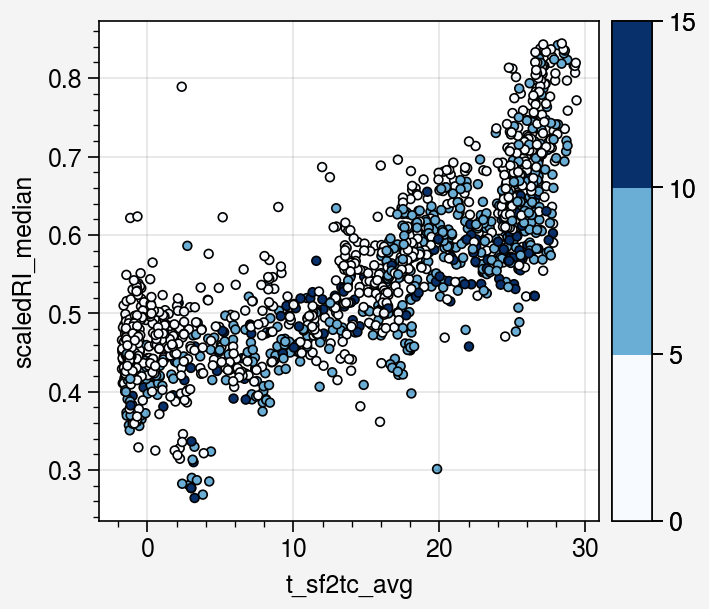

In [36]:
fig,  axs = plot.subplots()

ax = axs[0]
plot_x = coretop_df['t_sf2tc_avg']
plot_y = coretop_df['scaledRI_median']
plot_c = coretop_df['gdgt23ratio_median']
m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
ax.colorbar(m, loc='r')